# SignBridge — ISL Landmark-Based Sign Classifier

This notebook trains a hand-landmark-based classifier (using MediaPipe Hands + a small MLP)
on the Indian Sign Language "Gesture-Speech" dataset from Kaggle, instead of a raw-pixel CNN.

**Why landmarks instead of pixels:** the source dataset consists of stylized grayscale
renders on a black background. A pixel-based CNN (MobileNetV2) trained on this data does not
generalize to real camera photos. Landmark coordinates (hand joint positions) are a more
robust intermediate representation, but MediaPipe's hand detector still needs to successfully
locate hands in the source images first — this notebook includes a diagnostic step to check
that before committing to a full extraction pass.

## Expected project folder layout

```
SignBridge/
├── requirements.txt
├── SuperBridge_Landmark.ipynb        <- this notebook
├── dataset - Gesture Speech/         <- extracted Kaggle dataset (a/, b/, c/, ... z/, {/)
│   ├── a/
│   ├── b/
│   └── ...
├── artifacts/                        <- created automatically by this notebook
│   ├── landmark_dataset.npz
│   ├── best_landmark_model.keras
│   ├── signbridge_landmark_model.keras
│   └── label_classes.npy
└── test_images/                      <- put your own real test photos here (optional)
```

## Setup (run once, in a terminal, before opening this notebook)

```bash
cd SignBridge
python3 -m venv .venv
source .venv/bin/activate          # on Windows: .venv\Scripts\activate
pip install --upgrade pip
pip install -r requirements.txt
```

Then select the `.venv` interpreter as this notebook's kernel.

Cell 1 below also runs `pip install` for convenience so the notebook is self-contained,
but running it via the terminal first (as above) is recommended — it's faster and easier
to read errors from a terminal than from a notebook cell.


In [6]:
# Optional: installs everything from requirements.txt directly from the notebook.
# Safe to re-run. If you already installed via the terminal (recommended), this
# cell will just confirm everything is present and do nothing further.
import sys, subprocess

req_path = "requirements.txt"
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", req_path], check=True)
print("Dependencies OK.")


Dependencies OK.


In [7]:
# ---- Imports ----
import os
import json
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)
print("MediaPipe version:", mp.__version__)
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


NumPy version: 1.26.4
OpenCV version: 4.10.0
MediaPipe version: 0.10.14
TensorFlow version: 2.16.2
GPU devices: []


In [8]:
# ---- Config: paths ----
# CHANGE THIS to the folder that directly contains the class subfolders (a/, b/, c/, ... {/)
DATASET_DIR = "/Users/pranav/Desktop/SignBridge/dataset - Gesture Speech"

ARTIFACTS_DIR = "./artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

LANDMARK_NPZ_PATH = os.path.join(ARTIFACTS_DIR, "landmark_dataset.npz")
BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "best_landmark_model.keras")
FINAL_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "signbridge_landmark_model.keras")
LABEL_CLASSES_PATH = os.path.join(ARTIFACTS_DIR, "label_classes.npy")


def find_dataset_root(start_path):
    """Walk start_path looking for the folder that directly contains class
    subfolders 'a' and 'b'. Falls back to start_path itself if not found."""
    if not os.path.isdir(start_path):
        raise FileNotFoundError(
            f"DATASET_DIR does not exist: {start_path}\n"
            "Edit the DATASET_DIR variable above to point at your dataset folder."
        )
    for root, dirs, _files in os.walk(start_path):
        dirs_lower = [d.lower() for d in dirs]
        if "a" in dirs_lower and "b" in dirs_lower:
            return root
    return start_path


data_root = find_dataset_root(DATASET_DIR)
class_dirs = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d)) and not d.startswith(".")])

print("Detected data root:", data_root)
print("Classes found:", class_dirs)
print("Num classes:", len(class_dirs))

assert len(class_dirs) > 0, "No class subfolders found — check DATASET_DIR."


Detected data root: /Users/pranav/Desktop/SignBridge/dataset - Gesture Speech
Classes found: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{']
Num classes: 27


In [9]:
# ---- MediaPipe hand-landmark extraction ----
mp_hands = mp.solutions.hands


def extract_two_hand_landmarks(img_rgb, hands_detector):
    """Runs MediaPipe Hands on an RGB image and returns a fixed-length 126-dim
    feature vector: 21 landmarks x 3 coords x 2 hands (Left then Right).
    Missing hand -> zeros for that half of the vector.
    Returns None if no hand at all was detected."""
    res = hands_detector.process(img_rgb)
    if not res.multi_hand_landmarks or not res.multi_handedness:
        return None

    hands_dict = {}
    for lm, handedness in zip(res.multi_hand_landmarks, res.multi_handedness):
        label = handedness.classification[0].label  # "Left" or "Right"
        coords = np.array([[p.x, p.y, p.z] for p in lm.landmark], dtype=np.float32)

        # Normalize: center on wrist, scale by wrist-to-middle-MCP distance
        wrist = coords[0]
        coords = coords - wrist
        scale = np.linalg.norm(coords[9]) + 1e-6
        coords = coords / scale

        hands_dict[label] = coords.flatten()  # 21 * 3 = 63 values

    left = hands_dict.get("Left", np.zeros(63, dtype=np.float32))
    right = hands_dict.get("Right", np.zeros(63, dtype=np.float32))
    return np.concatenate([left, right])  # 126-dim feature vector


def load_image_rgb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [10]:
# ---- Diagnostic: how reliably does MediaPipe detect hands in this dataset? ----
# Run this BEFORE the full extraction. If most classes show 0 or 1 out of N,
# the dataset's visual style is a poor match for MediaPipe's hand detector and
# the full extraction below will silently skip a large fraction of images.

def spot_check_detection(data_root, class_dirs, n_per_class=8, min_detection_confidence=0.3):
    summary = {}
    with mp_hands.Hands(static_image_mode=True, max_num_hands=2,
                         min_detection_confidence=min_detection_confidence) as hands:
        for letter in class_dirs:
            class_dir = os.path.join(data_root, letter)
            files = [f for f in os.listdir(class_dir) if not f.startswith(".")][:n_per_class]
            any_hand, two_hand = 0, 0
            for f in files:
                img_rgb = load_image_rgb(os.path.join(class_dir, f))
                if img_rgb is None:
                    continue
                res = hands.process(img_rgb)
                n_hands = len(res.multi_hand_landmarks) if res.multi_hand_landmarks else 0
                if n_hands >= 1:
                    any_hand += 1
                if n_hands == 2:
                    two_hand += 1
            summary[letter] = {"any_hand": f"{any_hand}/{len(files)}", "two_hand": f"{two_hand}/{len(files)}"}
    return summary


detection_summary = spot_check_detection(data_root, class_dirs, n_per_class=8)
for letter, stats in detection_summary.items():
    print(f"{letter}: at least 1 hand = {stats['any_hand']}   both hands = {stats['two_hand']}")


I0000 00:00:1785697879.058465 9415085 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785697879.072941 9417482 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785697879.081714 9417482 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/pranav/Desktop/SignBridge/.venv/lib/python3.12/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


a: at least 1 hand = 7/8   both hands = 3/8
b: at least 1 hand = 8/8   both hands = 6/8
c: at least 1 hand = 8/8   both hands = 0/8
d: at least 1 hand = 5/8   both hands = 3/8
e: at least 1 hand = 8/8   both hands = 6/8
f: at least 1 hand = 7/8   both hands = 2/8
g: at least 1 hand = 7/8   both hands = 0/8
h: at least 1 hand = 5/8   both hands = 0/8
i: at least 1 hand = 6/8   both hands = 0/8
j: at least 1 hand = 7/8   both hands = 2/8
k: at least 1 hand = 5/8   both hands = 5/8
l: at least 1 hand = 8/8   both hands = 0/8
m: at least 1 hand = 6/8   both hands = 4/8
n: at least 1 hand = 6/8   both hands = 0/8
o: at least 1 hand = 8/8   both hands = 0/8
p: at least 1 hand = 7/8   both hands = 1/8
q: at least 1 hand = 7/8   both hands = 1/8
r: at least 1 hand = 4/8   both hands = 0/8
s: at least 1 hand = 7/8   both hands = 1/8
t: at least 1 hand = 8/8   both hands = 7/8
u: at least 1 hand = 8/8   both hands = 0/8
v: at least 1 hand = 5/8   both hands = 0/8
w: at least 1 hand = 8/8   both 

### Checkpoint

Look at the printed detection rates above before continuing.

- If **"at least 1 hand"** is high (most classes near N/N) but **"both hands"** is low for
  some classes, that likely just means those classes are genuinely single-hand poses —
  fine, the feature vector zero-pads the missing hand.
- If **"at least 1 hand"** itself is low (many 0/N or 1/N) across most classes, MediaPipe is
  struggling to parse this dataset's rendering style. The extraction below will still run and
  will report how many images got skipped — a high skip rate (>15-20%) is a signal that this
  dataset may not be reliable training data regardless of which model architecture you use on
  top of it, and collecting a small amount of real webcam data may be the more effective next
  step rather than continuing to tune this pipeline.


In [11]:
# ---- Full landmark extraction (checkpointed, resumable) ----
def build_landmark_dataset(data_root, class_dirs, out_path, save_every=2000,
                            min_detection_confidence=0.3):
    X, y, skipped = [], [], 0

    all_files = []
    for letter in class_dirs:
        class_dir = os.path.join(data_root, letter)
        for fname in os.listdir(class_dir):
            if fname.startswith("."):
                continue
            all_files.append((letter, os.path.join(class_dir, fname)))

    with mp_hands.Hands(static_image_mode=True, max_num_hands=2,
                         min_detection_confidence=min_detection_confidence) as hands:
        for i, (letter, fpath) in enumerate(tqdm(all_files, desc="Extracting landmarks")):
            img_rgb = load_image_rgb(fpath)
            if img_rgb is None:
                skipped += 1
                continue
            feat = extract_two_hand_landmarks(img_rgb, hands)
            if feat is None:
                skipped += 1
                continue
            X.append(feat)
            y.append(letter)

            if (i + 1) % save_every == 0:
                np.savez(out_path, X=np.array(X), y=np.array(y), class_names=np.array(class_dirs))

    X = np.array(X)
    y = np.array(y)
    np.savez(out_path, X=X, y=y, class_names=np.array(class_dirs))
    total = len(all_files)
    print(f"Done. Extracted {len(X)} / {total} samples ({len(X)/total*100:.1f}%). Skipped {skipped}.")
    return X, y


if os.path.exists(LANDMARK_NPZ_PATH):
    print(f"Found existing extraction at {LANDMARK_NPZ_PATH} — skipping re-extraction.")
    print("Delete that file (or change LANDMARK_NPZ_PATH) if you want to re-run extraction.")
    _data = np.load(LANDMARK_NPZ_PATH, allow_pickle=True)
    X, y_labels = _data["X"], _data["y"]
else:
    X, y_labels = build_landmark_dataset(data_root, class_dirs, LANDMARK_NPZ_PATH)


Found existing extraction at ./artifacts/landmark_dataset.npz — skipping re-extraction.
Delete that file (or change LANDMARK_NPZ_PATH) if you want to re-run extraction.


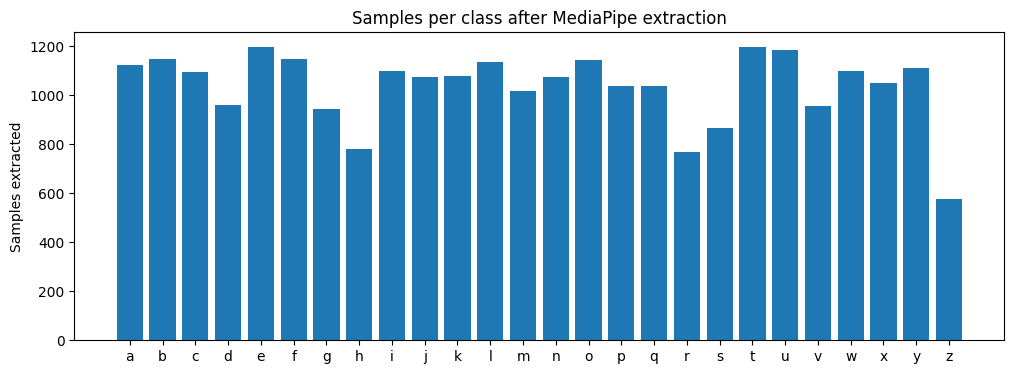

a: 1125
b: 1147
c: 1097
d: 960
e: 1198
f: 1150
g: 944
h: 783
i: 1098
j: 1077
k: 1081
l: 1135
m: 1018
n: 1077
o: 1146
p: 1039
q: 1039
r: 769
s: 868
t: 1198
u: 1187
v: 955
w: 1098
x: 1051
y: 1110
z: 578


In [12]:
# ---- Sanity check: class balance after extraction ----
unique, counts = np.unique(y_labels, return_counts=True)
plt.figure(figsize=(12, 4))
plt.bar(unique, counts)
plt.xticks(rotation=0)
plt.ylabel("Samples extracted")
plt.title("Samples per class after MediaPipe extraction")
plt.show()

for u, c in zip(unique, counts):
    print(f"{u}: {c}")


In [13]:
# ---- Encode labels, split train/val/test ----
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)
num_classes = len(le.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Classes:", list(le.classes_))


Train: (18849, 126)  Val: (4039, 126)  Test: (4040, 126)
Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [14]:
# ---- Build and train the landmark MLP ----
landmark_model = models.Sequential([
    layers.Input(shape=(126,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax"),
])

landmark_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

landmark_model.summary()

early_stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor="val_accuracy", save_best_only=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

history = landmark_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint, reduce_lr],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        32,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,298 (274.60 KB)

 Trainable params: 69,530 (271.60 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7499 - loss: 0.8760 - val_accuracy: 0.8987 - val_loss: 0.3508 - learning_rate: 0.0010
Epoch 2/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8632 - loss: 0.4416 - val_accuracy: 0.9265 - val_loss: 0.2430 - learning_rate: 0.0010
Epoch 3/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8909 - loss: 0.3385 - val_accuracy: 0.9282 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 4/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9009 - loss: 0.3068 - val_accuracy: 0.9438 - val_loss: 0.1901 - learning_rate: 0.0010
Epoch 5/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9140 - loss: 0.2707 - val_accuracy: 0.9473 - val_loss: 0.1709 - learning_rate: 0.0010
Epoch 6/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9169 - loss: 0.2551 - val_accuracy: 0.9512 - val_loss: 0.1523 - learning_rate: 0.0010
Epoch 7/100
590/590 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9218 - loss: 0.

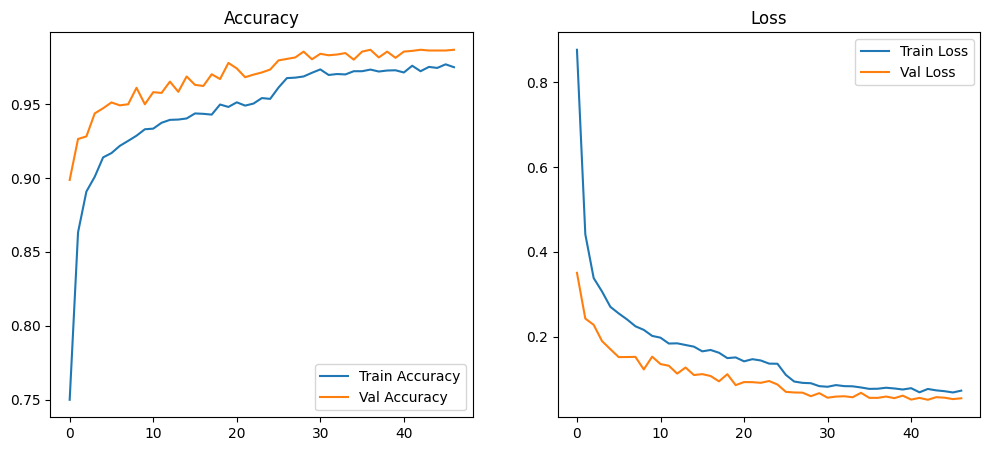

In [15]:
# ---- Training curves ----
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss")
plt.show()


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.9849 - loss: 0.0609
Test Accuracy: 98.49%
Test Loss: 0.0609
              precision    recall  f1-score   support

           a       1.00      1.00      1.00       169
           b       0.98      0.99      0.99       172
           c       0.98      0.98      0.98       165
           d       1.00      0.97      0.98       144
           e       0.99      1.00      0.99       180
           f       0.99      0.99      0.99       173
           g       0.99      0.99      0.99       141
           h       1.00      0.97      0.99       117
           i       1.00      0.99      0.99       165
           j       1.00      0.98      0.99       162
           k       0.99      1.00      0.99       162
           l       0.99      0.99      0.99       171
           m       0.95      0.96      0.95       152
           n       0.95      0.95      0.95       162
           o       0.95      1.00      0.97       172
           p      

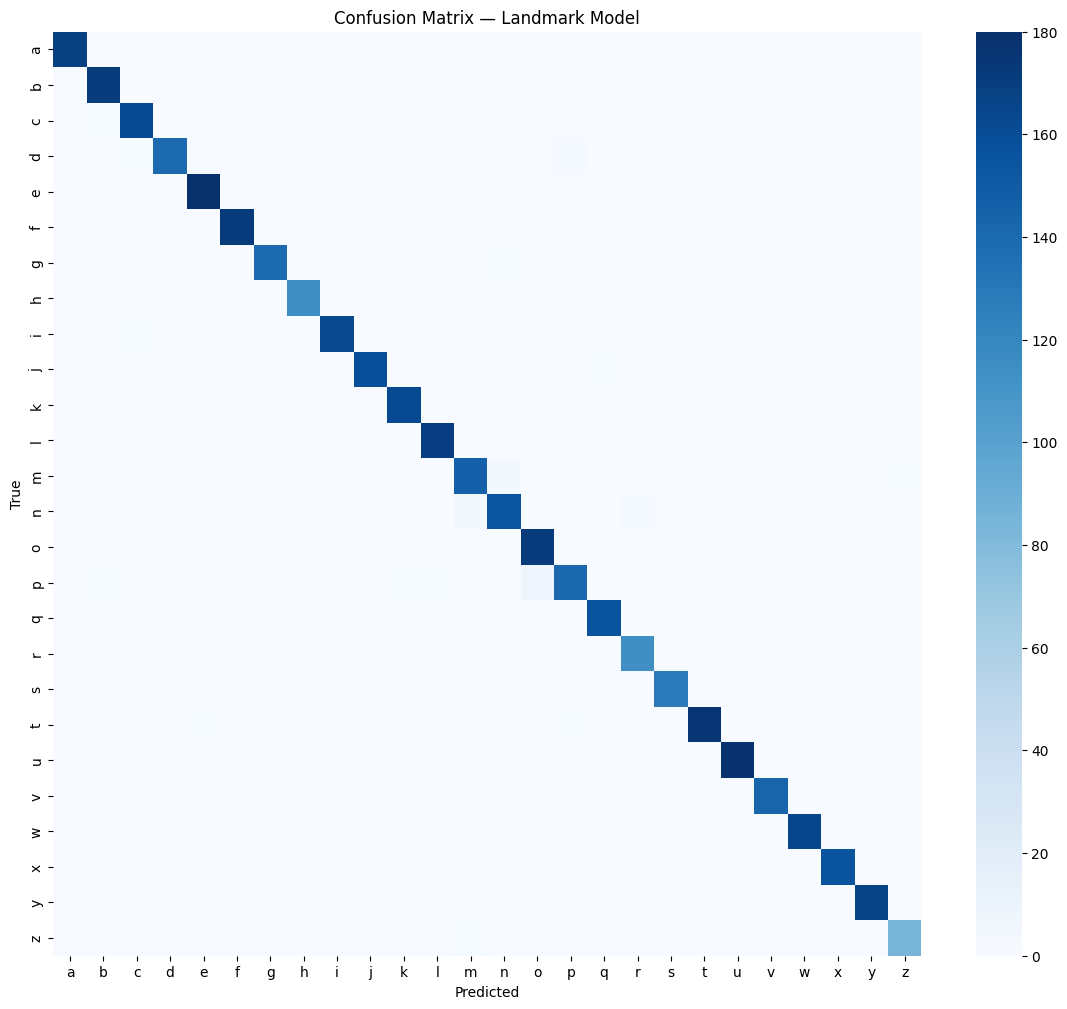

In [16]:
# ---- Evaluate on held-out test set ----
test_loss, test_acc = landmark_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = landmark_model.predict(X_test, verbose=0)
y_true_idx = np.argmax(y_test, axis=1)
y_pred_idx = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true_idx, y_pred_idx, target_names=le.classes_))

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Landmark Model")
plt.show()


In [17]:
# ---- Save model + label encoder ----
landmark_model.save(FINAL_MODEL_PATH)
np.save(LABEL_CLASSES_PATH, le.classes_)
print("Saved model to:", FINAL_MODEL_PATH)
print("Saved label classes to:", LABEL_CLASSES_PATH)


Saved model to: ./artifacts/signbridge_landmark_model.keras
Saved label classes to: ./artifacts/label_classes.npy


In [21]:
# ---- Inference on a single image, with a confidence guard ----
CONFIDENCE_THRESHOLD = 60  # tune based on validation behavior on real photos

def predict_sign_landmarks(img_path, hands_detector=None, model=None, label_classes=None):
    if model is None:
        model = landmark_model
    if label_classes is None:
        label_classes = le.classes_

    img_rgb = load_image_rgb(img_path)
    if img_rgb is None:
        return {"error": f"Could not read image: {img_path}"}

    close_after = False
    if hands_detector is None:
        hands_detector = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.3)
        close_after = True

    feat = extract_two_hand_landmarks(img_rgb, hands_detector)
    if close_after:
        hands_detector.close()

    if feat is None:
        return {"error": "No hand(s) detected in image"}

    preds = model.predict(feat.reshape(1, -1), verbose=0)[0]
    idx = np.argmax(preds)
    confidence = round(float(preds[idx]) * 100, 2)
    label = label_classes[idx]

    if confidence < CONFIDENCE_THRESHOLD:
        return {"alphabet": "Unknown", "confidence": confidence, "raw_top_guess": str(label).upper()}
    return {"alphabet": str(label).upper(), "confidence": confidence}


predict_sign_landmarks("/Users/pranav/Desktop/SignBridge/image3.jpg")


I0000 00:00:1785698266.936938 9415085 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1785698266.953287 9423611 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785698267.048009 9423613 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


{'alphabet': 'R', 'confidence': 98.98}

## Optional: live webcam inference

The cell below opens a webcam window and runs live predictions. It's disabled by default
(`RUN_WEBCAM = False`) so that "Run All" doesn't hang waiting on a camera loop. Set it to
`True` and re-run the cell manually when you want to try it. Press **q** to close the window.


In [19]:
# ---- Optional: live webcam inference (manual use only) ----
RUN_WEBCAM = False

if RUN_WEBCAM:
    cap = cv2.VideoCapture(0)
    with mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5) as hands:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame = cv2.flip(frame, 1)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            feat = extract_two_hand_landmarks(frame_rgb, hands)
            label_text = "No hand detected"
            if feat is not None:
                preds = landmark_model.predict(feat.reshape(1, -1), verbose=0)[0]
                idx = np.argmax(preds)
                conf = float(preds[idx]) * 100
                label = le.classes_[idx]
                label_text = f"{'Unknown' if conf < CONFIDENCE_THRESHOLD else str(label).upper()} ({conf:.1f}%)"

            cv2.putText(frame, label_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
            cv2.imshow("SignBridge - press q to quit", frame)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

    cap.release()
    cv2.destroyAllWindows()
else:
    print("RUN_WEBCAM is False — set it to True and re-run this cell to try live webcam inference.")


RUN_WEBCAM is False — set it to True and re-run this cell to try live webcam inference.
